# MECH 309: Assignment 6, Question 3

_Cagri Arslan_

April 15, 2026

*All work can be found on https://github.com/imported-canuck/MECH-309*

In [1]:
# Imports

import importlib
import numpy as np
import matplotlib.pyplot as plt

import EOM
import heun

# 3) Orbital EOM with Heun's Method and RK4

This notebook solves the normalized two-body problem

$$
\ddot{x}_s(t) = -\frac{x_s(t)}{r(t)^3}, 
\qquad
\ddot{y}_s(t) = -\frac{y_s(t)}{r(t)^3},
\qquad
r(t)=\sqrt{x_s(t)^2+y_s(t)^2},
$$

with $$GM=1$$ over one orbital period $$0 \le t \le 2\pi$$

The cases $$e=0,\;0.5,\;0.9$$ are tested using Heun's method and then compared with a fourth-order Runge–Kutta method (RK4).

# a)

We are given the normalized orbital equations of motion

$$
\ddot{x}_s(t) = -\frac{x_s(t)}{r(t)^3},
\qquad
\ddot{y}_s(t) = -\frac{y_s(t)}{r(t)^3},
\qquad
r(t)=\sqrt{x_s(t)^2+y_s(t)^2},
$$

with $GM=1$.

To write the problem as a first-order system, define the state vector

$$
\mathbf{x}(t)=
\begin{bmatrix}
x_s(t)\\
y_s(t)\\
\dot{x}_s(t)\\
\dot{y}_s(t)
\end{bmatrix}.
$$

Then

$$
\dot{\mathbf{x}}(t)=\mathbf{f}(\mathbf{x}(t)),
\qquad
\mathbf{x}(0)=\mathbf{x}_0,
$$

where

$$
\mathbf{f}(\mathbf{x})=
\begin{bmatrix}
\dot{x}_s\\
\dot{y}_s\\
-\dfrac{x_s}{(x_s^2+y_s^2)^{3/2}}\\
-\dfrac{y_s}{(x_s^2+y_s^2)^{3/2}}
\end{bmatrix}.
$$

For a given eccentricity $e$, the initial condition is

$$
\mathbf{x}_0=
\begin{bmatrix}
1-e\\
0\\
0\\
\sqrt{\dfrac{1+e}{1-e}}
\end{bmatrix}.
$$

This is the form required in part (a).

# b)

## i)

In this part, Heun's method is used to solve the orbital equations over one full period, from $t=0$ to $t=2\pi$, for the cases $e=0$, $e=0.5$, and $e=0.9$.

For each case, two things are examined:

1. The orbit in the $x$-$y$ plane.
2. The relative error in the total mechanical energy, defined by

$$
E_{\mathrm{rel}}=\frac{|E_k-E_0|}{|E_0|},
$$

where

$$
E_k=\frac{\dot{x}_{s,k}^2+\dot{y}_{s,k}^2}{2}-\frac{1}{r_k}.
$$

If the numerical method were exact, the orbit would close perfectly after one period and the total energy would remain constant. Any deviation from this behavior is numerical error.

In [2]:
# Helper function for running one Heun simulation case.
def run_heun_case(e, dt=1e-3, show_plots=True):
    # Construct the initial condition from the eccentricity.
    x0 = EOM.initial_state_from_eccentricity(e)

    # Solve the ODE over exactly one orbital period.
    time, states = EOM.solve_heun_exact_end(
        initial_state=x0,
        t_start=0.0,
        t_end=2.0 * np.pi,
        dt=dt,
        rhs_func=EOM.orbital_rhs,
    )

    # Compute the energy history and relative energy error.
    energies, relerr = EOM.compute_energy_history(states)

    # For part (b)(ii), the requested error is the 1-norm of the FULL state.
    state_error = EOM.compute_state_error(states, ord_norm=1)

    # Print a concise numerical summary.
    print(f"Heun, e = {e:.1f}")
    print(f"  ||x_K - x_0||_1      = {state_error:.6e}")
    print(f"  final E_rel          = {relerr[-1]:.6e}")
    print(f"  max E_rel            = {np.max(relerr):.6e}")
    print()

    # Plot the orbit and relative energy error if requested.
    if show_plots:
        EOM.plot_orbit(states[0:2, :], e)
        EOM.plot_time_series(
            time=time,
            values=relerr,
            xlabel=r"$t$",
            ylabel=r"$E_{\mathrm{rel}}$",
            title=f"Heun: relative energy error for e = {e:.1f}",
            label="Heun",
        )

    # Return everything in a dictionary so it can be reused later.
    return {
        "e": e,
        "time": time,
        "states": states,
        "energies": energies,
        "relerr": relerr,
        "state_error": state_error,
    }

Heun, e = 0.0
  ||x_K - x_0||_1      = 1.678936e-05
  final E_rel          = 3.141470e-09
  max E_rel            = 3.141470e-09



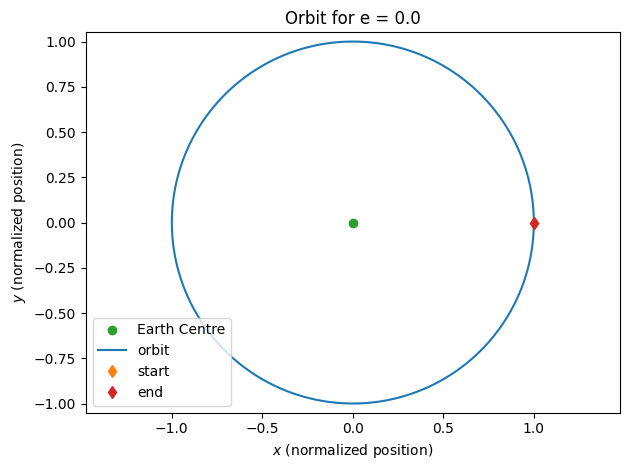

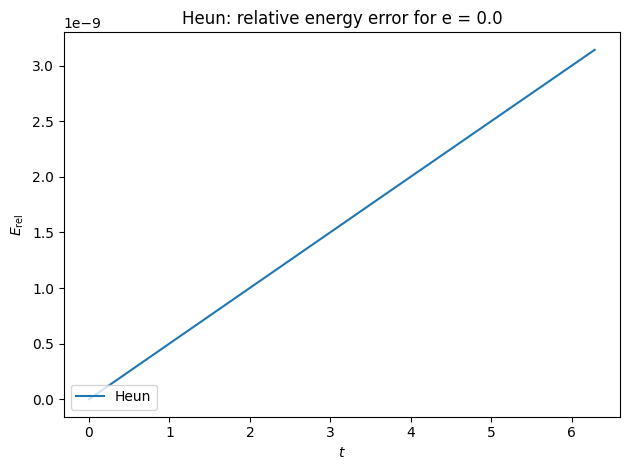

Heun, e = 0.5
  ||x_K - x_0||_1      = 3.878727e-04
  final E_rel          = 5.993913e-08
  max E_rel            = 6.647232e-06



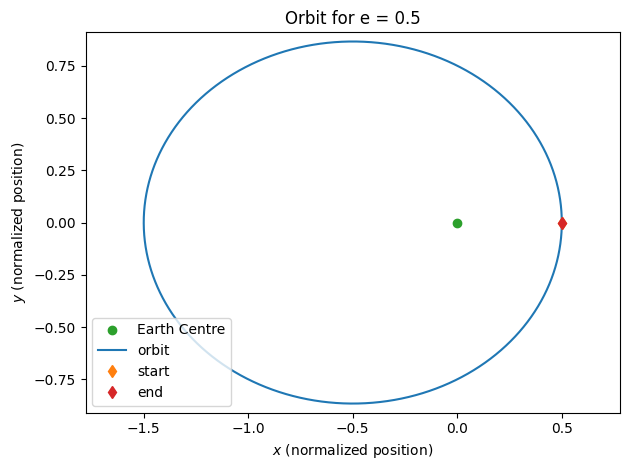

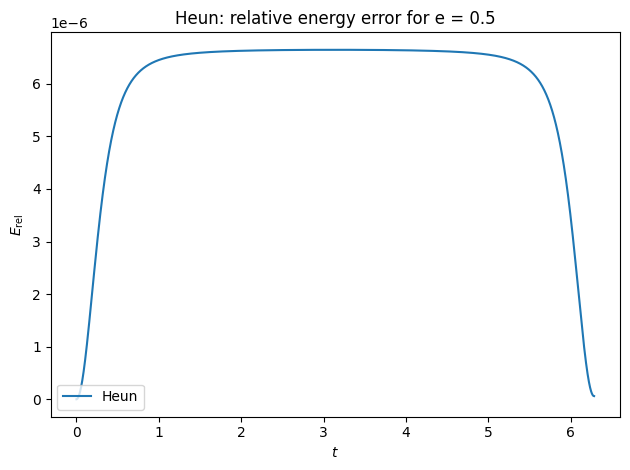

Heun, e = 0.9
  ||x_K - x_0||_1      = 4.464488e+00
  final E_rel          = 4.890549e-03
  max E_rel            = 5.053898e-03



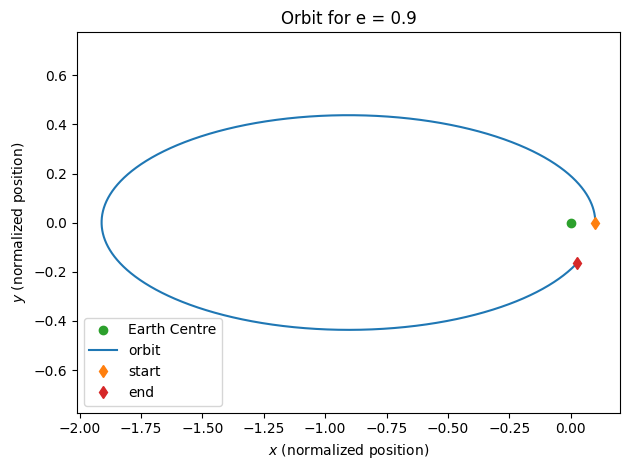

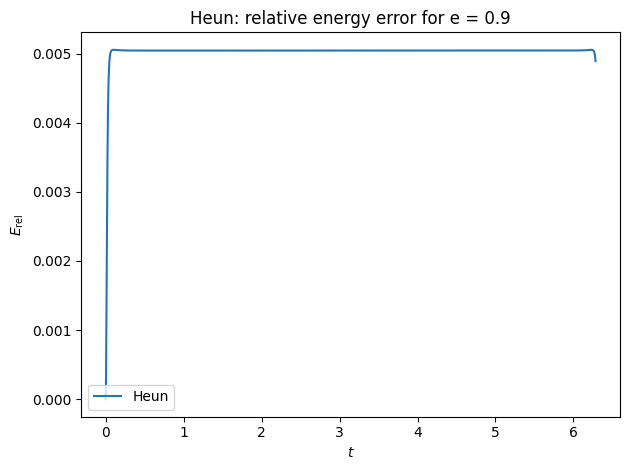

In [3]:
# Run all Heun cases requested in part (b).
heun_results = [run_heun_case(e) for e in (0.0, 0.5, 0.9)]

## ii)

The quantity requested in part (b)(ii) is the 1-norm error between the initial and final state after one orbit:

$$
\|\mathbf{x}_K-\mathbf{x}_0\|_1.
$$

The numerical values for each eccentricity are printed directly above. These values measure how closely the numerical solution returns to its initial state after one full orbital period. A smaller value indicates better orbital closure.

## iii)

The Heun results show that the numerical solution becomes less accurate as the eccentricity $e$ increases. This is expected, since larger eccentricity produces a more elongated orbit and a much more rapid change in velocity and acceleration near periapsis.

For the circular case $e=0$, the orbit remains nearly closed and the energy error stays extremely small. For $e=0.5$, the orbit still appears nearly closed visually, but the printed norm and energy-error values show that the numerical error has started to grow. For $e=0.9$, the orbit is much harder to resolve accurately with a fixed time step, and both the orbital closure error and energy drift are significantly larger.

There are three main reasons for this behavior:

1. Heun's method is only a second-order method, so its global truncation error is relatively large compared with higher-order methods.
2. The gravitational acceleration depends on $1/r^2$, so the dynamics change very rapidly when $r$ becomes small.
3. Heun's method is not energy-preserving, so even though the true mechanical energy is constant, the numerical energy drifts over time.

Therefore, the main problems with the Heun solution are imperfect orbital closure and increasing energy error, especially for large eccentricity.

# c)

## i)

To improve the numerical accuracy, a fourth-order Runge–Kutta method (RK4) is now implemented. The RK4 update is

$$
k_1=f(x_n),
\qquad
k_2=f\left(x_n+\frac{h}{2}k_1\right),
\qquad
k_3=f\left(x_n+\frac{h}{2}k_2\right),
\qquad
k_4=f(x_n+h k_3),
$$

and

$$
x_{n+1}=x_n+\frac{h}{6}\left(k_1+2k_2+2k_3+k_4\right).
$$

As in part (b), the orbit and the relative energy error are plotted for $e=0$, $e=0.5$, and $e=0.9$ over one period.

In [4]:
# Advance one time step using the classical fourth-order Runge-Kutta method.
def rk4_step(state, dt, rhs_func):
    # Stage 1: slope at the beginning of the interval.
    k1 = rhs_func(state)

    # Stage 2: slope at the midpoint, using k1.
    k2 = rhs_func(state + 0.5 * dt * k1)

    # Stage 3: another midpoint slope, now using k2.
    k3 = rhs_func(state + 0.5 * dt * k2)

    # Stage 4: slope at the end of the interval.
    k4 = rhs_func(state + dt * k3)

    # Weighted average of the four slopes.
    return state + (dt / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)


# Solve the ODE with RK4 while forcing the final time to land exactly at t_end.
def solve_rk4_exact_end(initial_state, t_start, t_end, dt, rhs_func):
    # Store time values and state values as lists, then convert at the end.
    times = [t_start]
    states = [np.asarray(initial_state, dtype=float).reshape(4, 1)]

    t = t_start
    while t < t_end - 1e-15:
        # Use the standard time step, except possibly on the last step.
        h = min(dt, t_end - t)

        # Advance one RK4 step.
        next_state = rk4_step(states[-1], h, rhs_func)

        # Append the new results.
        states.append(next_state)
        t += h
        times.append(t)

    return np.array(times), np.hstack(states)


# Run one RK4 simulation case and summarize the results.
def run_rk4_case(e, dt=1e-3, show_plots=True):
    # Construct the initial condition.
    x0 = EOM.initial_state_from_eccentricity(e)

    # Solve over exactly one orbital period.
    time, states = solve_rk4_exact_end(
        initial_state=x0,
        t_start=0.0,
        t_end=2.0 * np.pi,
        dt=dt,
        rhs_func=EOM.orbital_rhs,
    )

    # Compute energies and relative error.
    energies, relerr = EOM.compute_energy_history(states)

    # For part (c)(ii), the requested error is the 1-norm of POSITION only.
    position_error = EOM.compute_position_error(states, ord_norm=1)

    # Print a concise numerical summary.
    print(f"RK4, e = {e:.1f}")
    print(f"  ||r_K - r_0||_1      = {position_error:.6e}")
    print(f"  final E_rel          = {relerr[-1]:.6e}")
    print(f"  max E_rel            = {np.max(relerr):.6e}")
    print()

    # Plot the orbit and relative energy error if requested.
    if show_plots:
        EOM.plot_orbit(states[0:2, :], e)
        EOM.plot_time_series(
            time=time,
            values=relerr,
            xlabel=r"$t$",
            ylabel=r"$E_{\mathrm{rel}}$",
            title=f"RK4: relative energy error for e = {e:.1f}",
            label="RK4",
        )

    # Return everything for later comparison.
    return {
        "e": e,
        "time": time,
        "states": states,
        "energies": energies,
        "relerr": relerr,
        "position_error": position_error,
    }

RK4, e = 0.0
  ||r_K - r_0||_1      = 2.510442e-13
  final E_rel          = 9.769963e-15
  max E_rel            = 1.199041e-14



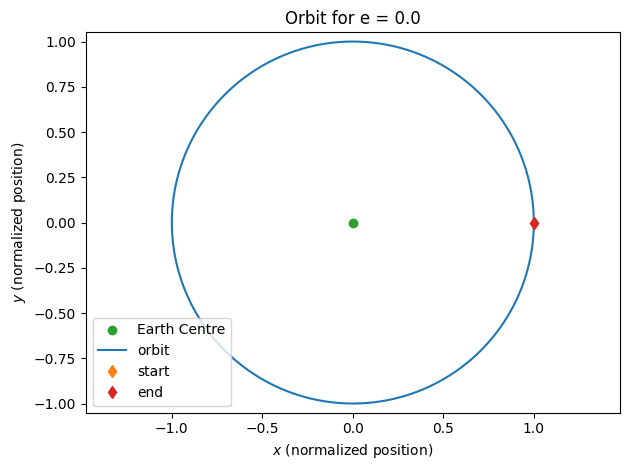

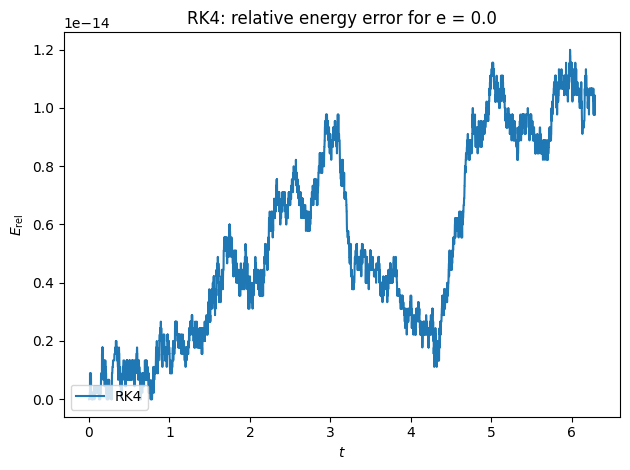

RK4, e = 0.5
  ||r_K - r_0||_1      = 1.824057e-11
  final E_rel          = 3.863576e-14
  max E_rel            = 1.174838e-12



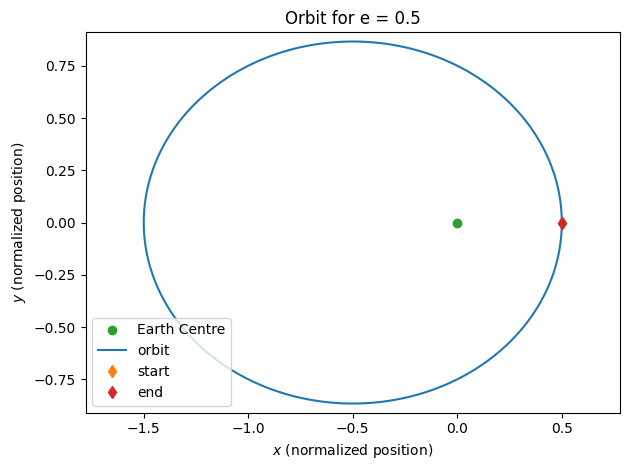

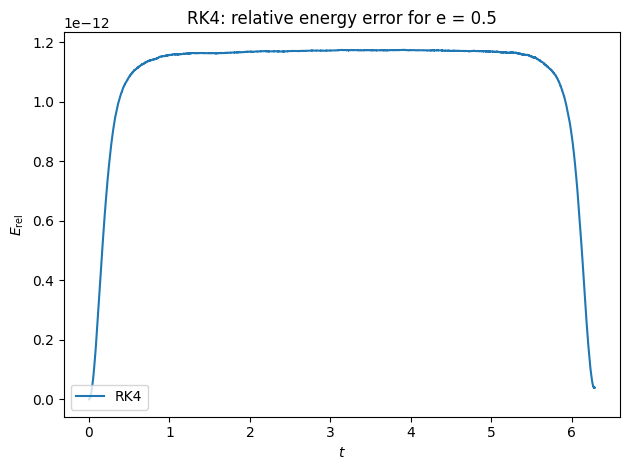

RK4, e = 0.9
  ||r_K - r_0||_1      = 7.257555e-06
  final E_rel          = 3.610287e-08
  max E_rel            = 1.766729e-07



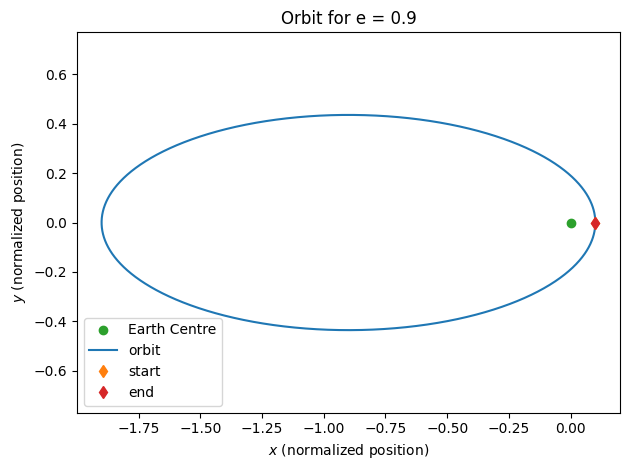

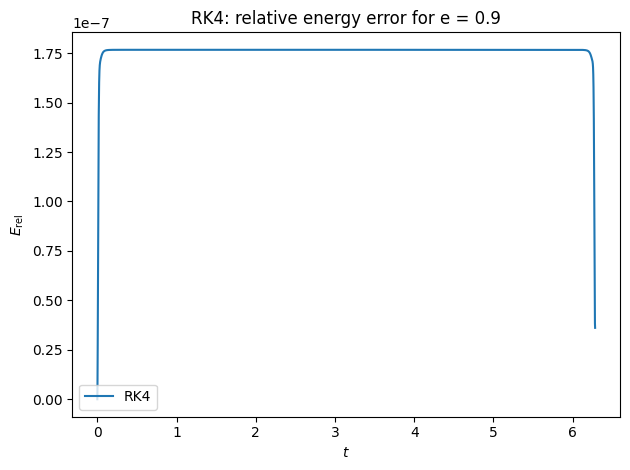

In [5]:
# Run all RK4 cases requested in part (c).
rk4_results = [run_rk4_case(e) for e in (0.0, 0.5, 0.9)]

## ii)

The quantity requested in part (c)(ii) is the 1-norm error between the initial and final position vectors after one orbit:

$$
\|\mathbf{r}_K-\mathbf{r}_0\|_1
=
\left\|
\begin{bmatrix}
x_s(t_K)\\
y_s(t_K)
\end{bmatrix}
-
\begin{bmatrix}
x_s(0)\\
y_s(0)
\end{bmatrix}
\right\|_1.
$$

These values are printed directly above for each eccentricity. As before, a smaller value indicates that the numerical orbit closes more accurately after one period.

## iii)

The RK4 method performs significantly better than Heun's method for the same step size. In particular, the RK4 orbit closes much more accurately after one period, and the relative energy error is substantially smaller.

This improvement occurs because RK4 is a fourth-order method, whereas Heun's method is only second-order. As a result, RK4 has a much smaller truncation error for the same value of $\Delta t$. The difference is especially important for the highly eccentric case $e=0.9$, where the spacecraft moves through the periapsis region very quickly and the solution changes rapidly.

For the $e=0$ RK4 case, the small jaggedness visible in the relative-energy-error plot is due to floating-point roundoff. Its magnitude is on the order of $10^{-14}$, so it is not physically meaningful and does not indicate any real loss of accuracy.

Comparing the two methods, RK4 addresses the main deficiencies observed with Heun's method:

1. It reduces the orbital closure error.
2. It greatly reduces the energy drift.
3. It remains much more reliable for larger eccentricities.

Therefore, RK4 is the more accurate method for this problem and gives results that are much closer to the expected physical behavior.

In [6]:
# Print a clean side-by-side numerical summary for the report.
print("Summary of Heun results:")
for res in heun_results:
    print(
        f"e = {res['e']:.1f} | "
        f"||x_K - x_0||_1 = {res['state_error']:.6e} | "
        f"max E_rel = {np.max(res['relerr']):.6e}"
    )

print("\nSummary of RK4 results:")
for res in rk4_results:
    print(
        f"e = {res['e']:.1f} | "
        f"||r_K - r_0||_1 = {res['position_error']:.6e} | "
        f"max E_rel = {np.max(res['relerr']):.6e}"
    )

Summary of Heun results:
e = 0.0 | ||x_K - x_0||_1 = 1.678936e-05 | max E_rel = 3.141470e-09
e = 0.5 | ||x_K - x_0||_1 = 3.878727e-04 | max E_rel = 6.647232e-06
e = 0.9 | ||x_K - x_0||_1 = 4.464488e+00 | max E_rel = 5.053898e-03

Summary of RK4 results:
e = 0.0 | ||r_K - r_0||_1 = 2.510442e-13 | max E_rel = 1.199041e-14
e = 0.5 | ||r_K - r_0||_1 = 1.824057e-11 | max E_rel = 1.174838e-12
e = 0.9 | ||r_K - r_0||_1 = 7.257555e-06 | max E_rel = 1.766729e-07


# Final remarks

From the results, the numerical accuracy clearly depends on both the choice of method and the eccentricity $e$.

Heun's method is acceptable for the easier cases, but its errors grow noticeably as the orbit becomes more eccentric. RK4 behaves much better for all three test cases and preserves the expected orbital behavior more accurately over one full period.

Overall, the results confirm that higher-order methods are much more suitable for this orbital simulation problem, especially when the trajectory contains regions of rapidly changing motion.